# VII. Explainability (XAI) — Transformer Classifier

Notebook de explicabilidad del modelo **GLU-Transformer** entrenado sobre datos de interacción del OULAD.

**Estrategia dual:**
1. **Intrínseca** — Extracción de mapas de atención por capa/cabeza para entender el foco temporal del modelo.
2. **Agnóstica** — SHAP (KernelExplainer) para cuantificar la contribución de cada variable (secuencial + estática) a la predicción.
3. **Análisis de errores** — Inspección de los casos más difíciles para el modelo.

> **Split analizado**: Validación  
> **Objetivo**: generar evidencia accionable para intervención educativa temprana.

## 1) Setup, dependencias y configuración

In [1]:
import os
import sys

sys.path.insert(0, '/workspace/TFM_education_ai_analytics')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_USE_LEGACY_KERAS'] = '0'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['CUDA_CACHE_DISABLE'] = '1'

EXECUTION_DEVICE = 'gpu'
if EXECUTION_DEVICE == 'cpu':
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
    print('✅ Ejecución forzada en CPU.')
else:
    print('✅ Ejecutando con la ruta GPU actual del proyecto.')

✅ Ejecutando con la ruta GPU actual del proyecto.


In [2]:
import os
import sys
import json
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, balanced_accuracy_score,
    roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score,
)

# ─── Estilo visual ────────────────────────────────────────────────────────────
DARK_BG   = '#0F1117'
PANEL_BG  = '#1A1D27'
GRID_CLR  = '#2A2D3A'
TEXT_CLR  = '#E8EAED'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,
    'axes.facecolor':   PANEL_BG,
    'text.color':       TEXT_CLR,
    'axes.labelcolor':  TEXT_CLR,
    'xtick.color':      TEXT_CLR,
    'ytick.color':      TEXT_CLR,
    'axes.edgecolor':   GRID_CLR,
    'grid.color':       GRID_CLR,
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
    'font.sans-serif':  ['DejaVu Sans'],
})
np.set_printoptions(suppress=True, precision=4)

# ─── Proyecto ─────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('/workspace/TFM_education_ai_analytics')
os.chdir(PROJECT_ROOT)

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DEL EXPERIMENTO  (✏️ editar aquí)
# ═══════════════════════════════════════════════════════════════════════════════
UPTO_WEEK    = 5
SPLIT        = 'validation'
NUM_CLASSES  = 2
BINARY_MODE  = 'paper'          # paper | original | success_vs_risk
WITH_STATIC  = True

# Derivar rutas automáticamente
TARGET_TAG   = f'{NUM_CLASSES}clases_{BINARY_MODE}' if NUM_CLASSES == 2 else f'{NUM_CLASSES}clases'
DATA_DIR     = PROJECT_ROOT / 'data' / '6_transformer_features'
MODEL_PATH   = PROJECT_ROOT / 'models' / 'transformers' / f'transformer_uptoW{UPTO_WEEK}_{TARGET_TAG}.keras'
HISTORY_PATH = PROJECT_ROOT / 'reports' / 'transformer_training' / f'week_{UPTO_WEEK}' / f'experiments_history_{TARGET_TAG}.json'
REPORT_DIR   = PROJECT_ROOT / 'reports' / 'transformer_training' / f'week_{UPTO_WEEK}'
HARDEST_CSV  = REPORT_DIR / f'hardest_val_examples_uptoW{UPTO_WEEK}_{TARGET_TAG}.csv'

print(f'Configuración:')
print(f'  Semana          : {UPTO_WEEK}')
print(f'  Split           : {SPLIT}')
print(f'  Clases          : {NUM_CLASSES} ({BINARY_MODE})')
print(f'  Con estáticas   : {WITH_STATIC}')
print(f'  Modelo          : {MODEL_PATH.name} (existe: {MODEL_PATH.exists()})')
print(f'  Historial       : {HISTORY_PATH.name} (existe: {HISTORY_PATH.exists()})')
print(f'  Hardest CSV     : {HARDEST_CSV.name} (existe: {HARDEST_CSV.exists()})')
print(f'  TensorFlow      : {tf.__version__}')

Configuración:
  Semana          : 5
  Split           : validation
  Clases          : 2 (paper)
  Con estáticas   : True
  Modelo          : transformer_uptoW5_2clases_paper.keras (existe: True)
  Historial       : experiments_history_2clases_paper.json (existe: True)
  Hardest CSV     : hardest_val_examples_uptoW5_2clases_paper.csv (existe: True)
  TensorFlow      : 2.22.0-dev0+selfbuilt


## 2) Carga de datos, modelo y utilidades

In [ ]:
mod_path = PROJECT_ROOT / 'educational_ai_analytics' / '2_modeling' / 'transformers' / 'transformer_GLU_classifier.py'
spec = importlib.util.spec_from_file_location('transformer_GLU_classifier', mod_path)
tg = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tg)

GLUTransformerClassifier = tg.GLUTransformerClassifier
TransformerEncoderBlock  = tg.TransformerEncoderBlock
GLULayer                 = tg.GLULayer


def load_npz_split(split: str, upto_week: int, with_static: bool = True):
    fp = DATA_DIR / split / f'transformer_uptoW{upto_week}.npz'
    d  = np.load(fp, allow_pickle=True)

    X_seq         = d['X_seq'].astype(np.float32)
    mask_pad      = (d['mask_pad'] if 'mask_pad' in d.files else d['mask']).astype(np.int32)
    mask_activity = (d['mask_activity'] if 'mask_activity' in d.files else mask_pad).astype(np.int32)
    y             = d['y'].astype(np.int64)
    ids           = d['ids'].astype(str)

    X_static = d['X_static'].astype(np.float32) if with_static else None

    static_feature_names = d['static_feature_names'] if 'static_feature_names' in d.files else np.array([], dtype=object)
    static_feature_sources = d['static_feature_sources'] if 'static_feature_sources' in d.files else np.array([], dtype=object)
    activities = d['activities'] if 'activities' in d.files else np.array([], dtype=object)

    return {
        'X_seq': X_seq, 'mask_pad': mask_pad, 'mask_activity': mask_activity,
        'y': y, 'ids': ids, 'X_static': X_static,
        'static_feature_names': static_feature_names,
        'static_feature_sources': static_feature_sources,
        'activities': activities,
    }


def filter_classes_binary(payload, binary_mode: str):
    y = payload['y']

    if binary_mode == 'paper':
        keep = y != 1
        y_bin = np.where(y[keep] == 0, 1, 0).astype(np.int64)
    elif binary_mode == 'original':
        keep = y != 0
        y_kept = y[keep]
        y_bin = np.where(y_kept == 1, 1, 0).astype(np.int64)
    elif binary_mode == 'success_vs_risk':
        keep = np.ones(len(y), dtype=bool)
        y_bin = np.where(y < 2, 1, 0).astype(np.int64)
    else:
        raise ValueError(f'binary_mode desconocido: {binary_mode}')

    result = {}
    for k, v in payload.items():
        if isinstance(v, np.ndarray) and v.shape[0] == len(y):
            result[k] = v[keep]
        else:
            result[k] = v
    result['y'] = y_bin
    return result


def load_model_from_history(model_path, history_path, upto_week):
    hist = json.loads(history_path.read_text(encoding='utf-8'))
    candidates = [r for r in hist if int(r.get('hyperparameters', {}).get('upto_week', -1)) == int(upto_week)]
    if not candidates:
        raise ValueError(f'No hay entradas en historial para upto_week={upto_week}')
    # El .keras por ventana se sobrescribe en cada reentrenamiento; la ultima fila es la que
    # corresponde al artefacto actual guardado en disco.
    hp = candidates[-1]['hyperparameters']

    custom_objects = {
        'GLUTransformerClassifier': GLUTransformerClassifier,
        'TransformerEncoderBlock': TransformerEncoderBlock,
        'GLULayer': GLULayer,
    }

    model = tf.keras.models.load_model(
        model_path,
        custom_objects=custom_objects,
        compile=False,
    )
    return model, hp


payload_raw = load_npz_split(SPLIT, UPTO_WEEK, with_static=WITH_STATIC)

if NUM_CLASSES == 2:
    payload = filter_classes_binary(payload_raw, BINARY_MODE)
else:
    payload = payload_raw

X_seq         = payload['X_seq']
mask_pad      = payload['mask_pad']
mask_activity = payload['mask_activity']
X_static      = payload['X_static']
y             = payload['y']
ids           = payload['ids']
activities    = payload['activities']
static_names  = payload['static_feature_names']

N, W, F = X_seq.shape
print(f'\n📊 Datos cargados ({SPLIT}):')
print(f'  X_seq:     {X_seq.shape}')
print(f'  X_static:  {X_static.shape if X_static is not None else "N/A"}')
print(f'  y:         {y.shape} | distribución: {dict(zip(*np.unique(y, return_counts=True)))}')
print(f'  IDs:       {ids.shape}')
print(f'  Semanas:   {W} | Features seq: {F} | Features estáticas: {X_static.shape[1] if X_static is not None else 0}')
print(f'  Actividades: {list(activities.astype(str)[:10])}...' if len(activities) > 10 else f'  Actividades: {list(activities.astype(str))}')

model, hp_loaded = load_model_from_history(
    model_path=MODEL_PATH,
    history_path=HISTORY_PATH,
    upto_week=UPTO_WEEK,
 )
print(f'\n✅ Modelo cargado: {MODEL_PATH.name}')
print(f'  Hiperparámetros: latent_d={hp_loaded.get("latent_d")}, num_heads={hp_loaded.get("num_heads")}, '
      f'ff_dim={hp_loaded.get("ff_dim")}, num_layers={hp_loaded.get("num_layers")}, dropout={hp_loaded.get("dropout")}')

inputs_val = [X_seq, mask_pad.astype(np.int32), mask_activity.astype(np.int32)]
if X_static is not None:
    inputs_val.append(X_static)

probs = model.predict(inputs_val, verbose=0)
y_pred = np.argmax(probs, axis=1)

bal_acc = balanced_accuracy_score(y, y_pred)
print(f'\n📈 Verificación rápida sobre {SPLIT}:')
print(f'  Balanced Accuracy: {bal_acc:.4f}')
print(f'  Confusion Matrix:\n{confusion_matrix(y, y_pred)}')
print(f'\n{classification_report(y, y_pred, digits=4)}')

if NUM_CLASSES == 2:
    auc_score = roc_auc_score(y, probs[:, 1])
    print(f'  AUC: {auc_score:.4f}')


📊 Datos cargados (validation):
  X_seq:     (3252, 5, 20)
  X_static:  (3252, 65)
  y:         (3252,) | distribución: {0: 2266, 1: 986}
  IDs:       (3252,)
  Semanas:   5 | Features seq: 20 | Features estáticas: 65
  Actividades: ['dataplus', 'dualpane', 'externalquiz', 'folder', 'forumng', 'glossary', 'homepage', 'htmlactivity', 'oucollaborate', 'oucontent']...

✅ Modelo cargado: transformer_uptoW5_2clases_paper.keras
  Hiperparámetros: latent_d=256, num_heads=8, ff_dim=128, num_layers=2, dropout=0.3

📈 Verificación rápida sobre validation:
  Balanced Accuracy: 0.7621
  Confusion Matrix:
[[1914  352]
 [ 316  670]]

              precision    recall  f1-score   support

           0     0.8583    0.8447    0.8514      2266
           1     0.6556    0.6795    0.6673       986

    accuracy                         0.7946      3252
   macro avg     0.7569    0.7621    0.7594      3252
weighted avg     0.7968    0.7946    0.7956      3252

  AUC: 0.8262


In [4]:
# Celda nueva: Saliency temporal (intrínseca)
import tensorflow as tf
import numpy as np

# Submuestra para no reventar memoria
n_explain = min(256, len(X_seq))
x_seq_e = tf.convert_to_tensor(X_seq[:n_explain])
m_pad_e = tf.convert_to_tensor(mask_pad[:n_explain].astype(np.int32))
m_act_e = tf.convert_to_tensor(mask_activity[:n_explain].astype(np.int32))
inputs_e = [x_seq_e, m_pad_e, m_act_e]
if X_static is not None:
    x_static_e = tf.convert_to_tensor(X_static[:n_explain])
    inputs_e.append(x_static_e)

with tf.GradientTape() as tape:
    tape.watch(x_seq_e)
    p = model(inputs_e, training=False)
    # prob de clase positiva en binario; en multi, usa clase predicha
    if NUM_CLASSES == 2:
        target = p[:, 1]
    else:
        cls = tf.argmax(p, axis=1)
        target = tf.gather(p, cls, axis=1, batch_dims=1)

grads = tape.gradient(target, x_seq_e).numpy()              # [N, W, F]
saliency_wf = np.mean(np.abs(grads), axis=0)                # [W, F]
saliency_w = saliency_wf.mean(axis=1)                       # [W]

print("Saliency temporal por semana:", saliency_w.round(4))

Saliency temporal por semana: [0.0025 0.0019 0.0015 0.0032 0.003 ]


In [5]:
# Celda nueva: SHAP KernelExplainer (agnóstico)
import shap
import numpy as np

N = len(X_seq)
W, F = X_seq.shape[1], X_seq.shape[2]
S = 0 if X_static is None else X_static.shape[1]

def pack_flat(x_seq, x_static=None):
    x = x_seq.reshape(len(x_seq), W * F)
    if x_static is not None:
        x = np.concatenate([x, x_static], axis=1)
    return x

def unpack_flat(x_flat):
    x_flat = np.asarray(x_flat)
    x_seq_u = x_flat[:, :W * F].reshape(-1, W, F).astype(np.float32)
    if S > 0:
        x_static_u = x_flat[:, W * F:].astype(np.float32)
    else:
        x_static_u = None
    return x_seq_u, x_static_u

def build_masks_from_seq(x_seq_u):
    # Para muestras sintéticas de SHAP no podemos reutilizar máscaras globales;
    # las derivamos por fila para mantener cardinalidad consistente.
    m_activity = (np.abs(x_seq_u).sum(axis=2) > 0).astype(np.int32)
    m_pad = np.ones_like(m_activity, dtype=np.int32)
    return m_pad, m_activity

def f_predict(x_flat):
    xs, xst = unpack_flat(x_flat)
    m_pad_s, m_act_s = build_masks_from_seq(xs)
    ins = [xs, m_pad_s, m_act_s]
    if xst is not None:
        ins.append(xst)
    p = model.predict(ins, verbose=0)
    return p[:, 1] if NUM_CLASSES == 2 else np.max(p, axis=1)

X_flat = pack_flat(X_seq, X_static)
bg_idx = np.random.choice(N, size=min(100, N), replace=False)
ex_idx = np.random.choice(N, size=min(80, N), replace=False)

explainer = shap.KernelExplainer(f_predict, X_flat[bg_idx])
shap_values = explainer.shap_values(X_flat[ex_idx], nsamples=200)

print('SHAP listo:', np.array(shap_values).shape)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 80/80 [01:28<00:00,  1.10s/it]

SHAP listo: (80, 165)


Top 15 features secuenciales:


,feature,mean_abs_shap
18,subpage,0.000502
14,quiz,0.000424
9,oucontent,0.000415
19,url,0.000403
16,resource,0.000389
8,oucollaborate,0.000294
2,externalquiz,0.000293
6,homepage,0.000274
12,page,0.000273
1,dualpane,0.000273


Top 15 features estáticas:


,feature,mean_abs_shap
11,api_index,0.020863
12,avg_score,0.018475
36,highest_education,0.010964
39,last_week_clicks_weighted,0.007688
40,late_ratio,0.004369
37,imd_band,0.003745
59,temporal_entropy_uptoW,0.002172
14,clicks_dualpane,0.002002
8,active_weeks,0.001992
57,studied_credits,0.001804


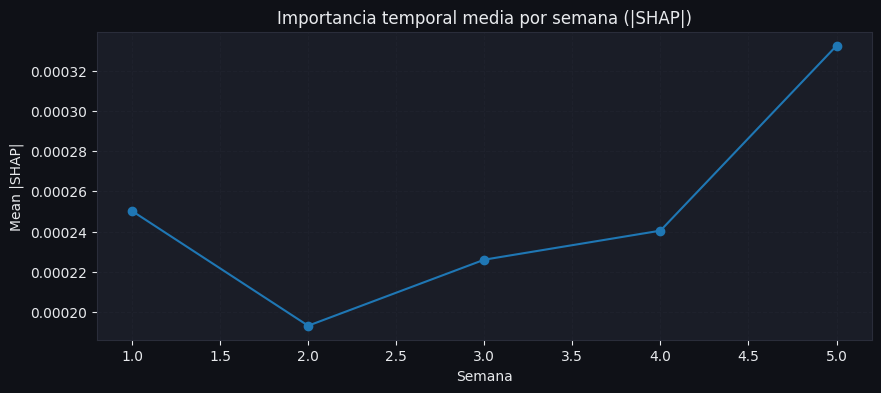

In [6]:
# 10) Resumen global de SHAP (importancia media |SHAP|)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Normalizar salida de SHAP (depende de versión/tipo de problema)
sv = shap_values
if isinstance(sv, list):
    # En binario, algunas versiones devuelven [clase0, clase1]
    sv = sv[1] if (NUM_CLASSES == 2 and len(sv) > 1) else sv[0]

sv = np.asarray(sv)
if sv.ndim == 3 and sv.shape[-1] == 1:
    sv = sv[..., 0]

# 2) Separar parte secuencial y estática
seq_cols = W * F
static_cols = S
assert sv.shape[1] == seq_cols + static_cols, (
    f"Columnas SHAP inesperadas: {sv.shape[1]} vs {seq_cols + static_cols}"
)

sv_seq = sv[:, :seq_cols].reshape(-1, W, F)   # [N, W, F]
imp_wf = np.abs(sv_seq).mean(axis=0)          # [W, F]
imp_week = imp_wf.mean(axis=1)                # [W]
imp_seq_feat = imp_wf.mean(axis=0)            # [F]

# Nombres de features secuenciales
if len(activities) == F:
    seq_feature_names = [str(a) for a in activities]
else:
    seq_feature_names = [f"seq_f{i}" for i in range(F)]

# 3) Top secuenciales
df_seq = pd.DataFrame({
    "feature": seq_feature_names,
    "mean_abs_shap": imp_seq_feat
}).sort_values("mean_abs_shap", ascending=False)

print("Top 15 features secuenciales:")
display(df_seq.head(15))

# 4) Top estáticas (si existen)
if S > 0:
    static_names_safe = [str(s) for s in static_names] if len(static_names) == S else [f"static_f{i}" for i in range(S)]
    imp_static = np.abs(sv[:, seq_cols:]).mean(axis=0)
    df_static = pd.DataFrame({
        "feature": static_names_safe,
        "mean_abs_shap": imp_static
    }).sort_values("mean_abs_shap", ascending=False)

    print("Top 15 features estáticas:")
    display(df_static.head(15))

# 5) Importancia temporal por semana
plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, W + 1), imp_week, marker='o')
plt.title("Importancia temporal media por semana (|SHAP|)")
plt.xlabel("Semana")
plt.ylabel("Mean |SHAP|")
plt.grid(True, alpha=0.3)
plt.show()

## 10.b) Comparativa compacta de SHAP entre semanas

Esta sección recalcula SHAP para varias ventanas `upto_week` y resume el resultado en una salida compacta:

- una tabla de métricas por ventana
- un heatmap con las features secuenciales más importantes por ventana
- un heatmap de importancia temporal por semana
- un heatmap de variables estáticas si existen

La idea es evitar cinco tablas independientes y quedarse con una vista comparativa única.

Ventanas a comparar: [5, 10, 15, 20, 25]


  3%|▎         | 1/30 [00:01<00:40,  1.41s/it]/opt/tfm-venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:688: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=1.124e-02, with an active set of 7 regressors, and the smallest cholesky pivot element being 8.429e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
 90%|█████████ | 27/30 [00:10<00:01,  2.74it/s]/opt/tfm-venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:688: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=2.864e-02, with an active set of 8 regressors, and the smallest cholesky pivot element being 8.429e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
  7%|▋         | 2/30 [00:01<00:23,  1.21it/s]/opt/tfm-venv/lib/python3.12/site-packages/shap/explainers/_kernel.py:708: UserWarning: Linear regression equation is singular, a least squar

Métricas por ventana:


,upto_week,n_samples,balanced_accuracy,auc,background_size,explain_size
0,5,3252,0.762087,0.826226,40,30
1,10,3290,0.829814,0.899755,40,30
2,15,3295,0.875258,0.936417,40,30
3,20,3299,0.920406,0.965801,40,30
4,25,3299,0.946036,0.986999,40,30


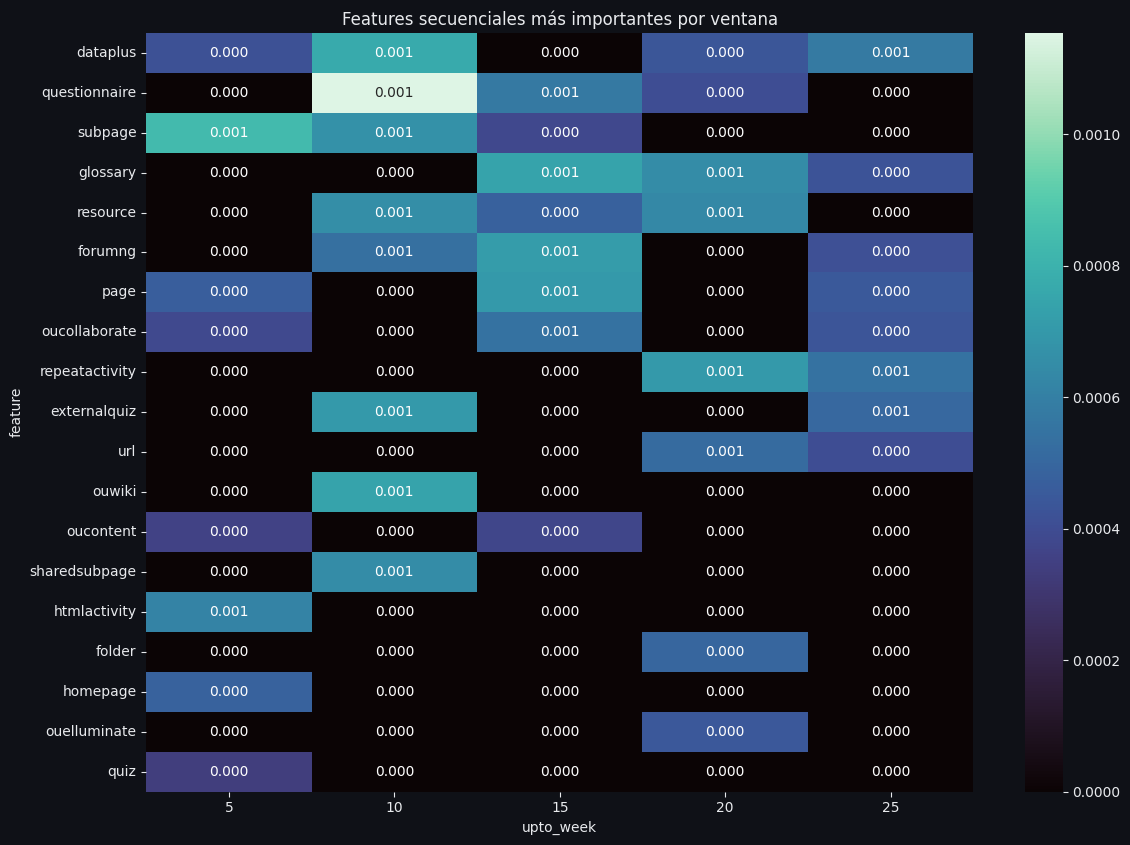

,upto_week,rank,feature,mean_abs_shap
0,5,1,subpage,0.000836
1,5,2,htmlactivity,0.000609
2,5,3,homepage,0.000478
3,5,4,page,0.000468
4,5,5,dataplus,0.000416
5,5,6,oucollaborate,0.000387
6,5,7,oucontent,0.000358
7,5,8,quiz,0.000334
8,10,1,questionnaire,0.001154
9,10,2,dataplus,0.000767


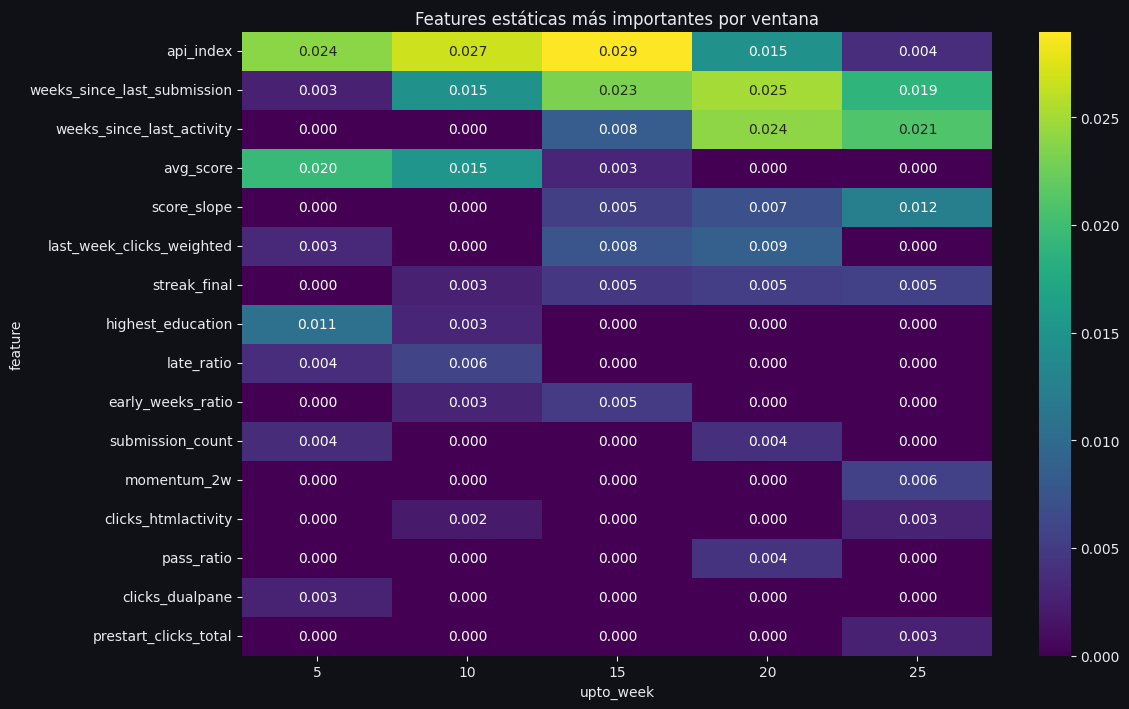

,upto_week,rank,feature,mean_abs_shap
0,5,1,api_index,0.023890
1,5,2,avg_score,0.019549
2,5,3,highest_education,0.010692
3,5,4,late_ratio,0.003657
4,5,5,submission_count,0.003588
5,5,6,last_week_clicks_weighted,0.003343
6,5,7,clicks_dualpane,0.002736
7,5,8,weeks_since_last_submission,0.002659
8,10,1,api_index,0.026812
9,10,2,avg_score,0.015052


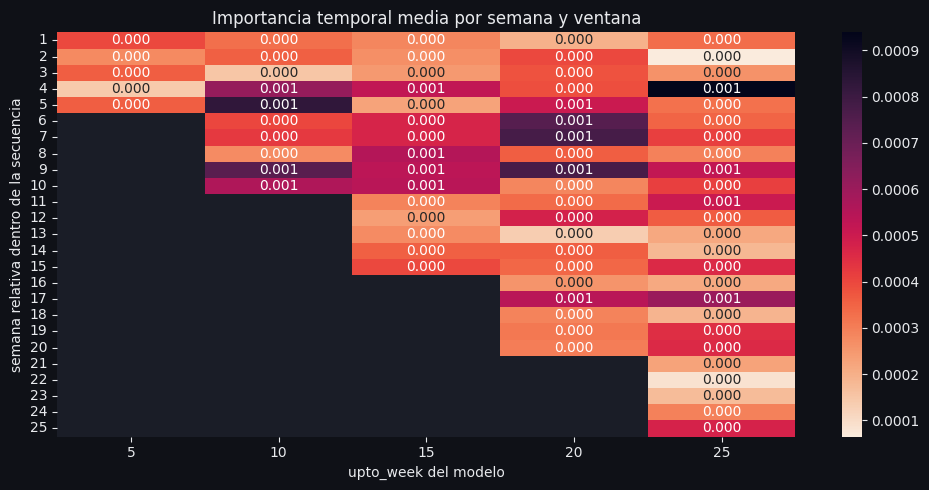

In [13]:
import shap
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

WEEKS_TO_COMPARE = sorted(
    int(path.stem.removeprefix('transformer_uptoW'))
    for path in (DATA_DIR / SPLIT).glob('transformer_uptoW*.npz')
    if path.stem.removeprefix('transformer_uptoW').isdigit()
 )

SHAP_BG_SIZE = 40
SHAP_EXPLAIN_SIZE = 30
SHAP_NSAMPLES = 120
TOP_K = 8
RNG = np.random.default_rng(42)

print('Ventanas a comparar:', WEEKS_TO_COMPARE)

def _normalize_shap_array(shap_values_obj):
    sv_local = shap_values_obj
    if isinstance(sv_local, list):
        sv_local = sv_local[1] if (NUM_CLASSES == 2 and len(sv_local) > 1) else sv_local[0]
    sv_local = np.asarray(sv_local)
    if sv_local.ndim == 3 and sv_local.shape[-1] == 1:
        sv_local = sv_local[..., 0]
    return sv_local

def _week_artifacts(upto_week):
    target_tag = f'{NUM_CLASSES}clases_{BINARY_MODE}' if NUM_CLASSES == 2 else f'{NUM_CLASSES}clases'
    model_path = PROJECT_ROOT / 'models' / 'transformers' / f'transformer_uptoW{upto_week}_{target_tag}.keras'
    history_path = PROJECT_ROOT / 'reports' / 'transformer_training' / f'week_{upto_week}' / f'experiments_history_{target_tag}.json'
    return model_path, history_path

metrics_rows = []
seq_rows = []
static_rows = []
temporal_rows = []

for upto_week in WEEKS_TO_COMPARE:
    model_path, history_path = _week_artifacts(upto_week)
    if not model_path.exists() or not history_path.exists():
        print(f'⚠️ Saltando W={upto_week}: faltan artefactos de modelo o historial.')
        continue

    payload_raw_w = load_npz_split(SPLIT, upto_week, with_static=WITH_STATIC)
    payload_w = filter_classes_binary(payload_raw_w, BINARY_MODE) if NUM_CLASSES == 2 else payload_raw_w

    X_seq_w = payload_w['X_seq']
    mask_pad_w = payload_w['mask_pad']
    mask_activity_w = payload_w['mask_activity']
    X_static_w = payload_w['X_static']
    y_w = payload_w['y']
    activities_w = payload_w['activities']
    static_names_w = payload_w['static_feature_names']

    model_w, hp_w = load_model_from_history(
        model_path=model_path,
        history_path=history_path,
        upto_week=upto_week,
    )

    inputs_w = [X_seq_w, mask_pad_w.astype(np.int32), mask_activity_w.astype(np.int32)]
    if X_static_w is not None:
        inputs_w.append(X_static_w)

    probs_w = model_w.predict(inputs_w, verbose=0)
    y_pred_w = np.argmax(probs_w, axis=1)
    bal_acc_w = float(balanced_accuracy_score(y_w, y_pred_w))
    auc_w = float(roc_auc_score(y_w, probs_w[:, 1])) if NUM_CLASSES == 2 else float(roc_auc_score(y_w, probs_w, multi_class='ovr'))

    N_w = len(X_seq_w)
    W_w = X_seq_w.shape[1]
    F_w = X_seq_w.shape[2]
    S_w = 0 if X_static_w is None else X_static_w.shape[1]

    def pack_flat_week(x_seq, x_static=None):
        x_flat = x_seq.reshape(len(x_seq), W_w * F_w)
        if x_static is not None:
            x_flat = np.concatenate([x_flat, x_static], axis=1)
        return x_flat

    def unpack_flat_week(x_flat):
        x_flat = np.asarray(x_flat)
        x_seq_u = x_flat[:, :W_w * F_w].reshape(-1, W_w, F_w).astype(np.float32)
        x_static_u = x_flat[:, W_w * F_w:].astype(np.float32) if S_w > 0 else None
        return x_seq_u, x_static_u

    def build_masks_week(x_seq_u):
        m_activity_u = (np.abs(x_seq_u).sum(axis=2) > 0).astype(np.int32)
        m_pad_u = np.ones_like(m_activity_u, dtype=np.int32)
        return m_pad_u, m_activity_u

    def f_predict_week(x_flat):
        xs, xst = unpack_flat_week(x_flat)
        m_pad_s, m_act_s = build_masks_week(xs)
        ins = [xs, m_pad_s, m_act_s]
        if xst is not None:
            ins.append(xst)
        p = model_w.predict(ins, verbose=0)
        return p[:, 1] if NUM_CLASSES == 2 else np.max(p, axis=1)

    X_flat_w = pack_flat_week(X_seq_w, X_static_w)
    bg_size = min(SHAP_BG_SIZE, N_w)
    ex_size = min(SHAP_EXPLAIN_SIZE, N_w)
    bg_idx_w = RNG.choice(N_w, size=bg_size, replace=False)
    ex_idx_w = RNG.choice(N_w, size=ex_size, replace=False)

    explainer_w = shap.KernelExplainer(f_predict_week, X_flat_w[bg_idx_w])
    shap_values_w = explainer_w.shap_values(X_flat_w[ex_idx_w], nsamples=SHAP_NSAMPLES)
    sv_w = _normalize_shap_array(shap_values_w)

    seq_cols_w = W_w * F_w
    sv_seq_w = sv_w[:, :seq_cols_w].reshape(-1, W_w, F_w)
    imp_wf_w = np.abs(sv_seq_w).mean(axis=0)
    imp_week_w = imp_wf_w.mean(axis=1)
    imp_seq_feat_w = imp_wf_w.mean(axis=0)

    seq_feature_names_w = [str(a) for a in activities_w] if len(activities_w) == F_w else [f'seq_f{i}' for i in range(F_w)]
    df_seq_w = pd.DataFrame({
        'feature': seq_feature_names_w,
        'mean_abs_shap': imp_seq_feat_w,
    }).sort_values('mean_abs_shap', ascending=False).head(TOP_K).reset_index(drop=True)

    for rank, row in enumerate(df_seq_w.itertuples(index=False), start=1):
        seq_rows.append({
            'upto_week': upto_week,
            'rank': rank,
            'feature': row.feature,
            'mean_abs_shap': float(row.mean_abs_shap),
        })

    if S_w > 0:
        static_names_safe_w = [str(s) for s in static_names_w] if len(static_names_w) == S_w else [f'static_f{i}' for i in range(S_w)]
        imp_static_w = np.abs(sv_w[:, seq_cols_w:]).mean(axis=0)
        df_static_w = pd.DataFrame({
            'feature': static_names_safe_w,
            'mean_abs_shap': imp_static_w,
        }).sort_values('mean_abs_shap', ascending=False).head(TOP_K).reset_index(drop=True)

        for rank, row in enumerate(df_static_w.itertuples(index=False), start=1):
            static_rows.append({
                'upto_week': upto_week,
                'rank': rank,
                'feature': row.feature,
                'mean_abs_shap': float(row.mean_abs_shap),
            })

    for week_idx, value in enumerate(imp_week_w, start=1):
        temporal_rows.append({
            'upto_week': upto_week,
            'relative_week': week_idx,
            'mean_abs_shap': float(value),
        })

    metrics_rows.append({
        'upto_week': upto_week,
        'n_samples': N_w,
        'balanced_accuracy': bal_acc_w,
        'auc': auc_w,
        'background_size': bg_size,
        'explain_size': ex_size,
    })

    tf.keras.backend.clear_session()

metrics_multiweek_df = pd.DataFrame(metrics_rows).sort_values('upto_week').reset_index(drop=True)
seq_multiweek_df = pd.DataFrame(seq_rows)
static_multiweek_df = pd.DataFrame(static_rows) if static_rows else pd.DataFrame()
temporal_multiweek_df = pd.DataFrame(temporal_rows)

print('Métricas por ventana:')
display(metrics_multiweek_df)

if not seq_multiweek_df.empty:
    seq_heatmap = seq_multiweek_df.pivot_table(
        index='feature',
        columns='upto_week',
        values='mean_abs_shap',
        aggfunc='max',
        fill_value=0.0,
    )
    seq_heatmap = seq_heatmap.loc[seq_heatmap.mean(axis=1).sort_values(ascending=False).index]
    plt.figure(figsize=(12, max(5, 0.45 * len(seq_heatmap))))
    sns.heatmap(seq_heatmap, cmap='mako', annot=True, fmt='.3f')
    plt.title('Features secuenciales más importantes por ventana')
    plt.xlabel('upto_week')
    plt.ylabel('feature')
    plt.tight_layout()
    plt.show()

display(seq_multiweek_df.sort_values(['upto_week', 'rank']).reset_index(drop=True))

if not static_multiweek_df.empty:
    static_heatmap = static_multiweek_df.pivot_table(
        index='feature',
        columns='upto_week',
        values='mean_abs_shap',
        aggfunc='max',
        fill_value=0.0,
    )
    static_heatmap = static_heatmap.loc[static_heatmap.mean(axis=1).sort_values(ascending=False).index]
    plt.figure(figsize=(12, max(5, 0.45 * len(static_heatmap))))
    sns.heatmap(static_heatmap, cmap='viridis', annot=True, fmt='.3f')
    plt.title('Features estáticas más importantes por ventana')
    plt.xlabel('upto_week')
    plt.ylabel('feature')
    plt.tight_layout()
    plt.show()

display(static_multiweek_df.sort_values(['upto_week', 'rank']).reset_index(drop=True))

if not temporal_multiweek_df.empty:
    temporal_heatmap = temporal_multiweek_df.pivot(
        index='relative_week',
        columns='upto_week',
        values='mean_abs_shap',
    ).sort_index()
    plt.figure(figsize=(10, 5))
    sns.heatmap(temporal_heatmap, cmap='rocket_r', annot=True, fmt='.3f')
    plt.title('Importancia temporal media por semana y ventana')
    plt.xlabel('upto_week del modelo')
    plt.ylabel('semana relativa dentro de la secuencia')
    plt.tight_layout()
    plt.show()

Capas de atencion capturadas: 2
Shape por capa [B, H, W, W]: [(128, 8, 5, 5), (128, 8, 5, 5)]


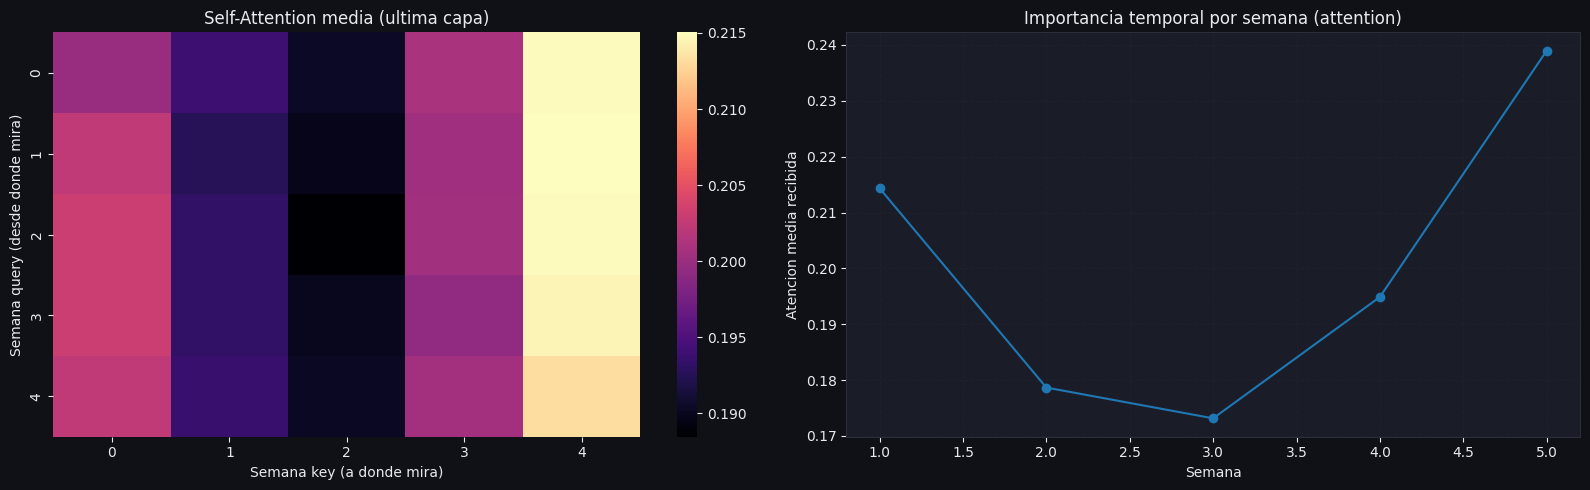

Top semanas por atencion media:


,week,attention_received
4,5,0.238975
0,1,0.214345
3,4,0.194873
1,2,0.178658
2,3,0.173147


In [11]:
# 11) Attention Maps intrinsecos (self-attention por capa/cabeza)
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Submuestra para explicabilidad
n_attn = min(128, len(X_seq))
x_seq_a = tf.convert_to_tensor(X_seq[:n_attn], dtype=tf.float32)
seq_mask_a = tf.convert_to_tensor(mask_pad[:n_attn].astype(np.int32))
act_mask_a = tf.convert_to_tensor(mask_activity[:n_attn].astype(np.int32))

if X_static is not None:
    x_static_a = tf.convert_to_tensor(X_static[:n_attn], dtype=tf.float32)
else:
    x_static_a = None

# ---- Forward manual del backbone para capturar attention_scores ----
x = model.input_proj(x_seq_a)

if getattr(model, "with_static_features", False) and (x_static_a is not None):
    x_static_emb = model.static_block(x_static_a, training=False)          # (B, D)
    x_static_t = tf.expand_dims(x_static_emb, axis=1)                      # (B, 1, D)
    x_static_t = tf.broadcast_to(x_static_t, tf.shape(x))                  # (B, W, D)
    fusion_in = tf.concat([x, x_static_t], axis=-1)                        # (B, W, 2D)
    gate = model.fusion_gate(fusion_in)                                    # (B, W, D)
    x = (1.0 - gate) * x + gate * x_static_t

x = model.in_drop(x, training=False)

attn_layers = []
for enc in model.encoders:
    attn_mask = enc.make_attn_mask(seq_mask_a)  # (B, W, W)

    # Bloque attention (como en call), pero devolviendo scores
    h = enc.norm_attn(x)
    attn_out, attn_scores = enc.mha(
        h, h, h,
        attention_mask=attn_mask,
        return_attention_scores=True,
        training=False,
    )
    attn_out = enc.drop_attn(attn_out, training=False)
    x = x + attn_out

    # Bloque FFN
    h2 = enc.norm_ffn(x)
    ffn = enc.ffn_glu(h2)
    ffn = enc.ffn_out(ffn)
    ffn = enc.drop_ffn(ffn, training=False)
    x = x + ffn

    a = attn_scores.numpy()
    # Esperado: (B, H, W, W). Si viene (B, W, W), anadimos eje de heads.
    if a.ndim == 3:
        a = a[:, None, :, :]
    attn_layers.append(a)

print(f"Capas de atencion capturadas: {len(attn_layers)}")
print("Shape por capa [B, H, W, W]:", [a.shape for a in attn_layers])

# ---- Agregaciones ----
# Matriz (W, W) por capa: promedio en batch + heads
attn_mean_by_layer = [a.mean(axis=(0, 1)) for a in attn_layers]

# Importancia temporal por semana (cuanta atencion recibe cada semana-key)
# promedio sobre: capas, batch, heads, query
attn_all = np.stack(attn_layers, axis=0)                  # (L, B, H, W, W)
attn_week_importance = attn_all.mean(axis=(0, 1, 2, 3))   # (W,)

# ---- Visualizaciones ----
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(attn_mean_by_layer[-1], cmap="magma", ax=axes[0])
axes[0].set_title("Self-Attention media (ultima capa)")
axes[0].set_xlabel("Semana key (a donde mira)")
axes[0].set_ylabel("Semana query (desde donde mira)")

axes[1].plot(np.arange(1, W + 1), attn_week_importance, marker="o")
axes[1].set_title("Importancia temporal por semana (attention)")
axes[1].set_xlabel("Semana")
axes[1].set_ylabel("Atencion media recibida")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla para reporte
attn_df = pd.DataFrame({
    "week": np.arange(1, W + 1),
    "attention_received": attn_week_importance
}).sort_values("attention_received", ascending=False)

print("Top semanas por atencion media:")
display(attn_df.head(10))

## 11.b) Comparativa compacta de atención entre semanas

Esta sección replica el análisis intrínseco de atención para todas las ventanas disponibles y lo resume sin generar una salida repetitiva por cada modelo.

Se muestran:

- una tabla con la semana más atendida por cada `upto_week`
- un heatmap de atención media recibida por semana relativa
- una rejilla con la matriz de self-attention media de la última capa para cada ventana

Resumen de atención por ventana:


,upto_week,n_attn_samples,num_layers,top_attention_week,top_attention_received
0,5,128,2,5,0.238975
1,10,128,2,10,0.153413
2,15,128,2,3,0.081197
3,20,128,2,2,0.067653
4,25,128,2,23,0.057428


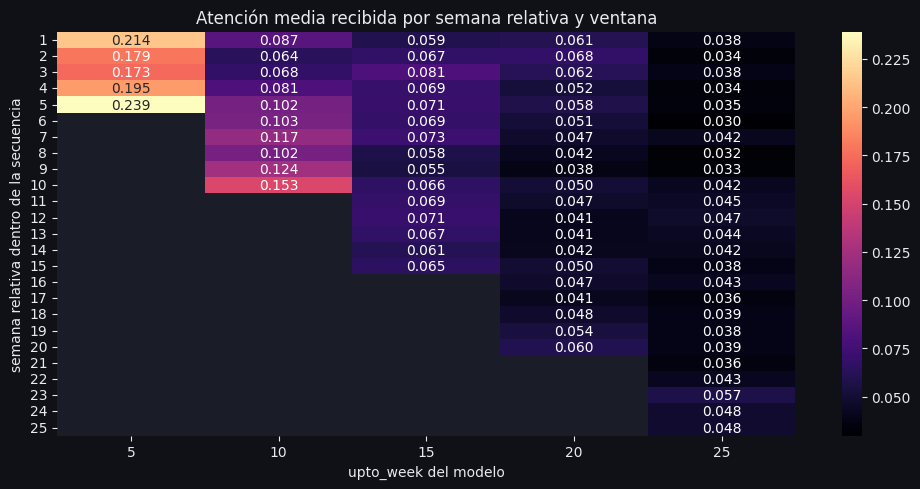

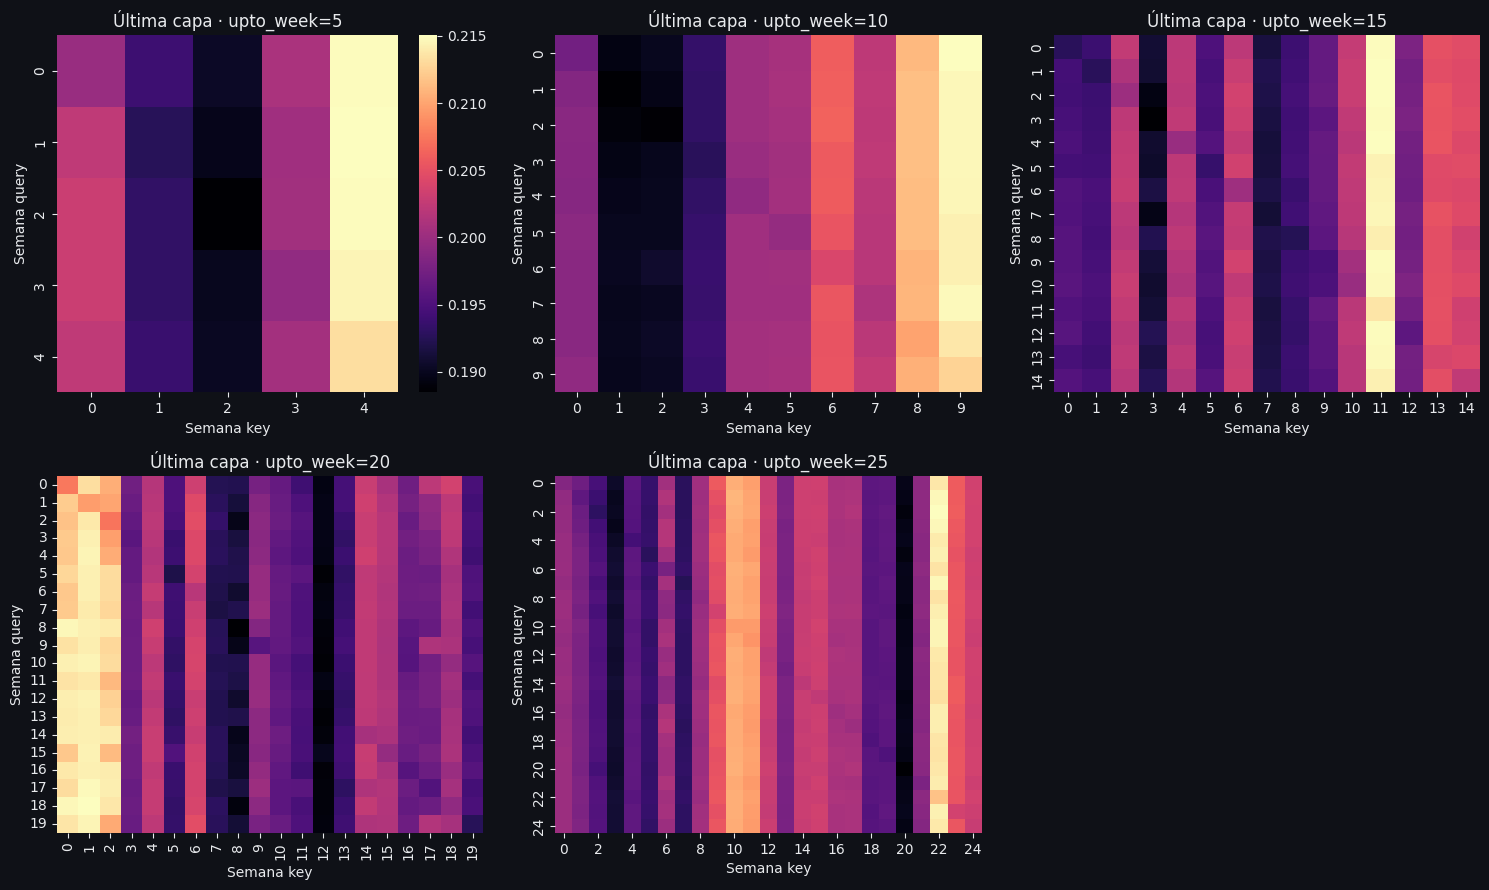

In [16]:
import math


def extract_attention_summary(model_obj, x_seq_np, mask_pad_np, mask_activity_np, x_static_np=None, max_samples=128):
    n_attn_local = min(max_samples, len(x_seq_np))
    x_seq_local = tf.convert_to_tensor(x_seq_np[:n_attn_local], dtype=tf.float32)
    seq_mask_local = tf.convert_to_tensor(mask_pad_np[:n_attn_local].astype(np.int32))
    act_mask_local = tf.convert_to_tensor(mask_activity_np[:n_attn_local].astype(np.int32))

    if x_static_np is not None:
        x_static_local = tf.convert_to_tensor(x_static_np[:n_attn_local], dtype=tf.float32)
    else:
        x_static_local = None

    x_local = model_obj.input_proj(x_seq_local)

    if getattr(model_obj, 'with_static_features', False) and (x_static_local is not None):
        x_static_emb_local = model_obj.static_block(x_static_local, training=False)
        x_static_t_local = tf.expand_dims(x_static_emb_local, axis=1)
        x_static_t_local = tf.broadcast_to(x_static_t_local, tf.shape(x_local))
        fusion_in_local = tf.concat([x_local, x_static_t_local], axis=-1)
        gate_local = model_obj.fusion_gate(fusion_in_local)
        x_local = (1.0 - gate_local) * x_local + gate_local * x_static_t_local

    x_local = model_obj.in_drop(x_local, training=False)

    attn_layers_local = []
    for enc_local in model_obj.encoders:
        attn_mask_local = enc_local.make_attn_mask(seq_mask_local)
        h_local = enc_local.norm_attn(x_local)
        attn_out_local, attn_scores_local = enc_local.mha(
            h_local, h_local, h_local,
            attention_mask=attn_mask_local,
            return_attention_scores=True,
            training=False,
        )
        attn_out_local = enc_local.drop_attn(attn_out_local, training=False)
        x_local = x_local + attn_out_local

        h2_local = enc_local.norm_ffn(x_local)
        ffn_local = enc_local.ffn_glu(h2_local)
        ffn_local = enc_local.ffn_out(ffn_local)
        ffn_local = enc_local.drop_ffn(ffn_local, training=False)
        x_local = x_local + ffn_local

        attn_array = attn_scores_local.numpy()
        if attn_array.ndim == 3:
            attn_array = attn_array[:, None, :, :]
        attn_layers_local.append(attn_array)

    attn_mean_by_layer_local = [a.mean(axis=(0, 1)) for a in attn_layers_local]
    attn_all_local = np.stack(attn_layers_local, axis=0)
    attn_week_importance_local = attn_all_local.mean(axis=(0, 1, 2, 3))

    return {
        'n_attn': n_attn_local,
        'num_layers': len(attn_layers_local),
        'attn_mean_by_layer': attn_mean_by_layer_local,
        'attn_week_importance': attn_week_importance_local,
    }


attention_rows = []
attention_temporal_rows = []
attention_last_layer_maps = {}

for upto_week in WEEKS_TO_COMPARE:
    model_path, history_path = _week_artifacts(upto_week)
    if not model_path.exists() or not history_path.exists():
        print(f'⚠️ Saltando W={upto_week}: faltan artefactos de modelo o historial.')
        continue

    payload_raw_w = load_npz_split(SPLIT, upto_week, with_static=WITH_STATIC)
    payload_w = filter_classes_binary(payload_raw_w, BINARY_MODE) if NUM_CLASSES == 2 else payload_raw_w

    X_seq_w = payload_w['X_seq']
    mask_pad_w = payload_w['mask_pad']
    mask_activity_w = payload_w['mask_activity']
    X_static_w = payload_w['X_static']

    model_w, hp_w = load_model_from_history(
        model_path=model_path,
        history_path=history_path,
        upto_week=upto_week,
    )

    attention_summary_w = extract_attention_summary(
        model_obj=model_w,
        x_seq_np=X_seq_w,
        mask_pad_np=mask_pad_w,
        mask_activity_np=mask_activity_w,
        x_static_np=X_static_w,
    )

    week_importance_w = attention_summary_w['attn_week_importance']
    top_week_idx = int(np.argmax(week_importance_w)) + 1

    attention_rows.append({
        'upto_week': upto_week,
        'n_attn_samples': attention_summary_w['n_attn'],
        'num_layers': attention_summary_w['num_layers'],
        'top_attention_week': top_week_idx,
        'top_attention_received': float(week_importance_w[top_week_idx - 1]),
    })

    for relative_week, value in enumerate(week_importance_w, start=1):
        attention_temporal_rows.append({
            'upto_week': upto_week,
            'relative_week': relative_week,
            'attention_received': float(value),
        })

    attention_last_layer_maps[upto_week] = attention_summary_w['attn_mean_by_layer'][-1]
    tf.keras.backend.clear_session()

attention_multiweek_df = pd.DataFrame(attention_rows).sort_values('upto_week').reset_index(drop=True)
attention_temporal_df = pd.DataFrame(attention_temporal_rows)

print('Resumen de atención por ventana:')
display(attention_multiweek_df)

if not attention_temporal_df.empty:
    attention_temporal_heatmap = attention_temporal_df.pivot(
        index='relative_week',
        columns='upto_week',
        values='attention_received',
    ).sort_index()

    plt.figure(figsize=(10, 5))
    sns.heatmap(attention_temporal_heatmap, cmap='magma', annot=True, fmt='.3f')
    plt.title('Atención media recibida por semana relativa y ventana')
    plt.xlabel('upto_week del modelo')
    plt.ylabel('semana relativa dentro de la secuencia')
    plt.tight_layout()
    plt.show()

if attention_last_layer_maps:
    ordered_weeks = sorted(attention_last_layer_maps)
    n_cols = min(3, len(ordered_weeks))
    n_rows = math.ceil(len(ordered_weeks) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, upto_week in zip(axes, ordered_weeks):
        sns.heatmap(attention_last_layer_maps[upto_week], cmap='magma', ax=ax, cbar=ax is axes[0])
        ax.set_title(f'Última capa · upto_week={upto_week}')
        ax.set_xlabel('Semana key')
        ax.set_ylabel('Semana query')

    for ax in axes[len(ordered_weeks):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [14]:
# 12) Marco de explicaciones accionables (XAI -> accion docente)
import numpy as np
import pandas as pd

# ---------- Utilidades ----------
def _normalize_shap_output(shap_values_obj, num_classes=2):
    sv = shap_values_obj
    if isinstance(sv, list):
        sv = sv[1] if (num_classes == 2 and len(sv) > 1) else sv[0]
    sv = np.asarray(sv)
    if sv.ndim == 3 and sv.shape[-1] == 1:
        sv = sv[..., 0]
    return sv


def _risk_band(p):
    if p >= 0.75:
        return "alto"
    if p >= 0.50:
        return "medio"
    return "bajo"


def _recommend_action(risk_prob, top_feats, attn_weeks):
    fset = set(top_feats)
    attn_txt = ", ".join([f"S{w}" for w in attn_weeks[:3]]) if len(attn_weeks) else "S?"

    if {"submission_count", "weeks_since_last_submission", "late_ratio"} & fset:
        return (
            "Plan de reenganche 7 dias: recordatorio activo, micro-entrega y tutoria breve.",
            "KPI: +1 entrega esta semana, reduccion de retraso y riesgo en proxima inferencia."
        )

    if {"avg_score", "score_slope", "api_index"} & fset:
        return (
            "Refuerzo academico focalizado: feedback de errores + actividad de recuperacion guiada.",
            "KPI: mejora de avg_score y api_index en 1-2 semanas."
        )

    if {"clicks_questionnaire", "clicks_externalquiz", "clicks_dualpane"} & fset:
        return (
            "Intervencion de participacion: secuencia corta de actividad evaluable en " + attn_txt + ".",
            "KPI: aumento de interacciones clave y continuidad semanal."
        )

    if risk_prob >= 0.75:
        return (
            "Seguimiento proactivo: contacto individual y plan semanal con hitos.",
            "KPI: mantener actividad semanal y bajar probabilidad de riesgo."
        )

    return (
        "Mantener seguimiento ligero con mensaje preventivo y objetivo semanal.",
        "KPI: estabilidad de participacion y rendimiento."
    )


# ---------- Entradas necesarias ----------
required_vars = ["shap_values", "ex_idx", "ids", "probs", "attn_week_importance", "W", "F", "S"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Faltan variables para esta celda: {missing}. Ejecuta antes celdas SHAP y Attention.")

sv = _normalize_shap_output(shap_values, num_classes=NUM_CLASSES)
seq_cols = W * F
all_cols = seq_cols + S

if sv.shape[1] != all_cols:
    raise RuntimeError(f"Shape SHAP inesperado: {sv.shape}. Esperado segunda dimension={all_cols}.")

# Nombres de features (secuenciales + estaticas)
if len(activities) == F:
    seq_feature_names = [str(a) for a in activities]
else:
    seq_feature_names = [f"seq_f{i}" for i in range(F)]

if S > 0:
    static_names_safe = [str(s) for s in static_names] if len(static_names) == S else [f"static_f{i}" for i in range(S)]
else:
    static_names_safe = []

feature_names = [f"seq::{n}" for n in seq_feature_names for _ in [0]]
# Expandimos seq names por semana para mapear W*F columnas
feature_names = [f"w{w+1}_{seq_feature_names[f]}" for w in range(W) for f in range(F)] + static_names_safe

# Semanas con mayor atencion global
top_attn_weeks = (np.argsort(attn_week_importance)[::-1] + 1).tolist()

# ---------- Construir tabla accionable por estudiante explicado en SHAP ----------
rows = []
for i, idx in enumerate(ex_idx):
    student_id = str(ids[idx])
    risk_prob = float(probs[idx, 1]) if NUM_CLASSES == 2 else float(np.max(probs[idx]))
    pred_class = int(np.argmax(probs[idx]))

    contrib = sv[i]  # contribuciones de este estudiante
    # Top features que empujan a riesgo (contrib positiva para clase riesgo en binario)
    top_pos_idx = np.argsort(contrib)[-5:][::-1]
    top_pos_pairs = [(feature_names[j], float(contrib[j])) for j in top_pos_idx]
    top_pos_features = [p[0] for p in top_pos_pairs]

    action, kpi = _recommend_action(risk_prob, top_pos_features, top_attn_weeks)

    rows.append({
        "student_id": student_id,
        "risk_prob": round(risk_prob, 4),
        "risk_band": _risk_band(risk_prob),
        "pred_class": pred_class,
        "top_shap_risk_features": "; ".join([f"{n} ({v:.3f})" for n, v in top_pos_pairs]),
        "attention_focus_weeks": ", ".join([f"S{w}" for w in top_attn_weeks[:3]]),
        "recommended_action": action,
        "kpi_followup": kpi,
    })

action_df = pd.DataFrame(rows).sort_values(["risk_prob"], ascending=False)

print("Vista previa de explicaciones accionables:")
display(action_df.head(20))

out_csv = REPORT_DIR / f"actionable_explanations_uptoW{UPTO_WEEK}_{TARGET_TAG}.csv"
action_df.to_csv(out_csv, index=False)
print(f"Guardado: {out_csv}")

Vista previa de explicaciones accionables:


,student_id,risk_prob,risk_band,pred_class,top_shap_risk_features,attention_focus_weeks,recommended_action,kpi_followup
45,650464_FFF_2014J,0.8234,alto,1,avg_score (0.058); api_index (0.050); active_r...,"S5, S1, S4",Refuerzo academico focalizado: feedback de err...,KPI: mejora de avg_score y api_index en 1-2 se...
58,592233_FFF_2014J,0.8228,alto,1,avg_score (0.048); w1_oucollaborate (0.044); w...,"S5, S1, S4",Refuerzo academico focalizado: feedback de err...,KPI: mejora de avg_score y api_index en 1-2 se...
8,618963_DDD_2014B,0.8175,alto,1,api_index (0.089); avg_score (0.068); highest_...,"S5, S1, S4",Refuerzo academico focalizado: feedback de err...,KPI: mejora de avg_score y api_index en 1-2 se...
33,598430_DDD_2013J,0.8171,alto,1,api_index (0.060); avg_score (0.057); last_wee...,"S5, S1, S4",Refuerzo academico focalizado: feedback de err...,KPI: mejora de avg_score y api_index en 1-2 se...
21,532468_BBB_2014B,0.8143,alto,1,avg_score (0.053); api_index (0.049); top1_sha...,"S5, S1, S4",Refuerzo academico focalizado: feedback de err...,KPI: mejora de avg_score y api_index en 1-2 se...
47,654001_BBB_2014J,0.8031,alto,1,api_index (0.050); last_week_clicks_weighted (...,"S5, S1, S4",Refuerzo academico focalizado: feedback de err...,KPI: mejora de avg_score y api_index en 1-2 se...
15,1656486_CCC_2014J,0.7855,alto,1,late_ratio (0.060); last_week_clicks_weighted ...,"S5, S1, S4",Plan de reenganche 7 dias: recordatorio activo...,"KPI: +1 entrega esta semana, reduccion de retr..."
77,593594_DDD_2013J,0.7575,alto,1,avg_score (0.052); late_ratio (0.041); api_ind...,"S5, S1, S4",Plan de reenganche 7 dias: recordatorio activo...,"KPI: +1 entrega esta semana, reduccion de retr..."
52,446746_FFF_2013J,0.7318,medio,1,temporal_entropy_uptoW (0.035); avg_score (0.0...,"S5, S1, S4",Refuerzo academico focalizado: feedback de err...,KPI: mejora de avg_score y api_index en 1-2 se...
56,256867_CCC_2014J,0.6826,medio,1,late_ratio (0.036); weekly_std_uptoW (0.026); ...,"S5, S1, S4",Plan de reenganche 7 dias: recordatorio activo...,"KPI: +1 entrega esta semana, reduccion de retr..."


Guardado: /workspace/TFM_education_ai_analytics/reports/transformer_training/week_5/actionable_explanations_uptoW5_2clases_paper.csv
